In [184]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping ,ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report ,confusion_matrix

import pandas as pd
import numpy as np
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

## 📍 Readinding Cleaned Dataset

In [185]:
df = pd.read_csv("/kaggle/input/datasets/youssef422129/agnews/CleanedAGNews.csv")
df

,CleanedText,CATEGORY
0,feed official say weak data cause weather slow...,b
1,feed charles plosser see high bar change pace ...,b
2,us open stock fall feed official hint accelera...,b
3,feed risk fall behind curve charles plosser say,b
4,feed plosser nasty weather curb job growth,b
...,...,...
422414,surgeons remove year old rib rebuild damage th...,m
422415,boy surgery esophagus battery burn hole throat,m
422416,child swallow battery reconstructive surgery c...,m
422417,phoenix boy undergo surgery repair throat dama...,m


## 📍 Check Null Values

In [186]:
df.isna().sum()

CleanedText    9
CATEGORY       0
dtype: int64

In [190]:
df.dropna(inplace=True)

## 📍 Calculate the true maximum sentence length

In [ ]:
true_max_len = df["CleanedText"].dropna().apply(lambda x: len(str(x).split())).max()
print(f"True Longest Sentence length = {true_max_len} words")

True Longest Sentence length = 3881 words


## 📍 Find the 95th and 99th percentiles

In [ ]:
lengths = df["CleanedText"].dropna().apply(lambda x: len(str(x).split()))

print(f"95% of titles are {lengths.quantile(0.95):.0f} words or shorter.")
print(f"99% of titles are {lengths.quantile(0.99):.0f} words or shorter.")

95% of titles are 10 words or shorter.
99% of titles are 11 words or shorter.


## 📍 Splitting Data

In [191]:
X = df["CleanedText"]
Y = df["CATEGORY"]
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3,random_state=42)

## 📍 Configure HyperParameters

In [192]:
VOCAB_SIZE = 20000
MAX_LEN = 13
NUM_CLASSES = 4

## 📍 Tokenization and padding Text

In [193]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [194]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

In [195]:
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

## 📍 Encoding Labels

In [196]:
label_encoder = LabelEncoder()
y_train_labels = label_encoder.fit_transform(y_train)
y_test_labels = label_encoder.transform(y_test)

NUM_CLASSES = len(label_encoder.classes_)

In [197]:
y_train_encoded = to_categorical(y_train_labels, num_classes=NUM_CLASSES)
y_test_encoded = to_categorical(y_test_labels, num_classes=NUM_CLASSES)

## 📍 Calculate Classes Weight

In [198]:
weights = class_weight.compute_class_weight(class_weight='balanced',classes=np.unique(y_train),y=y_train.values)
class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(0.9113315827107528), 1: np.float64(0.6925662381951732), 2: np.float64(2.311499374609131), 3: np.float64(0.9744881817103234)}


## 🟢 Some Info about Data

In [199]:
word_counts = tokenizer.word_counts
sorted_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

print(f"Total unique words found: {len(word_counts)}")
print(f"Word rank 10,000 appears {sorted_counts[15000][1]} times")

Total unique words found: 38739
Word rank 10,000 appears 5 times


## ✅ Start Building Model Arc

In [200]:
model = Sequential([
    Embedding(VOCAB_SIZE, 256, input_length=MAX_LEN),
    SpatialDropout1D(0.3), # Drops entire embedding channels
    Bidirectional(LSTM(128, return_sequences=True, use_bias=True)), # Reduced from 128
    Dropout(0.5),
    Bidirectional(LSTM(32, use_bias=True)),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])


early_stopping = EarlyStopping(monitor='val_loss', patience = 5, restore_best_weights=True)

## ✅ Training Phase

In [201]:
history = model.fit(X_train_padded,y_train_encoded,epochs=18,batch_size=256,validation_data=(X_test_padded, y_test_encoded),callbacks=[early_stopping],class_weight=class_weights)

Epoch 1/18
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.8396 - loss: 0.4209 - val_accuracy: 0.9403 - val_loss: 0.1742
Epoch 2/18
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9474 - loss: 0.1529 - val_accuracy: 0.9439 - val_loss: 0.1645
Epoch 3/18
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9569 - loss: 0.1222 - val_accuracy: 0.9445 - val_loss: 0.1676
Epoch 4/18
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9620 - loss: 0.1025 - val_accuracy: 0.9450 - val_loss: 0.1740
Epoch 5/18
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9659 - loss: 0.0909 - val_accuracy: 0.9441 - val_loss: 0.1757
Epoch 6/18
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9701 - loss: 0.0794 - val_accuracy: 0.9442 - val_loss: 0.1921
Epoch 7/18
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9729 - loss: 0.0692 - val_accuracy: 0.9453 - val_loss: 0.1950


## 🟢 Model Summary

In [202]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 13, 256)        │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_6             │ (None, 13, 256)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_22                │ (None, 13, 256)        │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 13, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_23                │ (None, 64)             │        73,984 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,765,454 (63.96 MB)

 Trainable params: 5,588,484 (21.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,176,970 (42.64 MB)

## ✅ Model Evaluation

In [203]:
results = model.evaluate(X_test_padded, y_test_encoded)
print(f"Validation Loss = {results[0]}")
print(f"Validation Accuracy = {results[1] * 100:0.2f} %")

3961/3961 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9439 - loss: 0.1640
Validation Loss = 0.16451004147529602
Validation Accuracy = 94.39 %


## 💹 Plotting Accuracy and Loss graphs

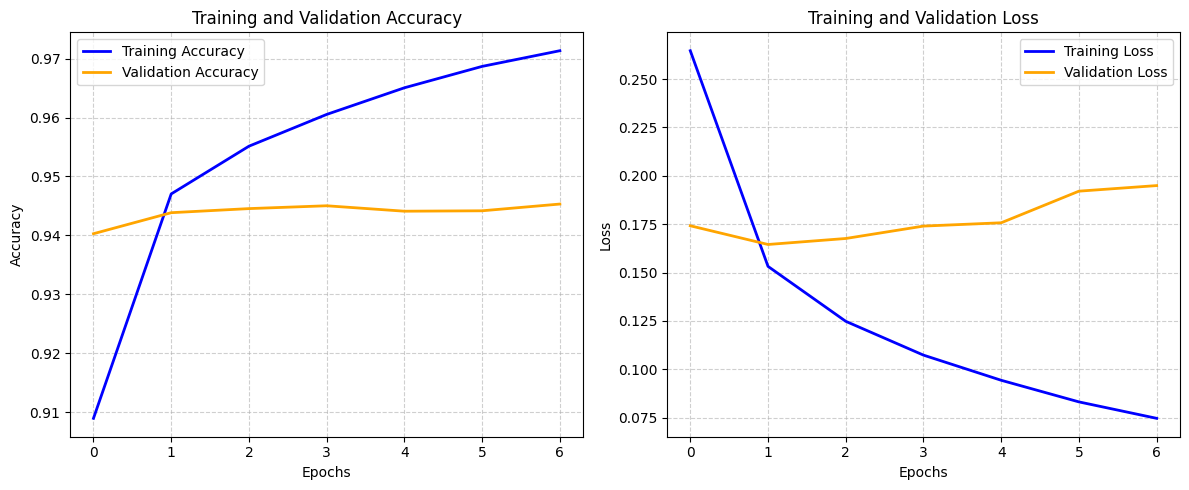

In [ ]:
plt.figure(figsize=(12, 5))

#! Plot 1: Accuracy 
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', lw=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', lw=2)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

#! Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', lw=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

---

<h1 align="center">✅ The End of NoteBook</h1>


---